In [1]:
import numpy as np
import pandas as pd


In [2]:
#Conectamos con el drive para bajar el dataframe
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path_file = "/content/drive/MyDrive/annual_deaths_by_causes.csv"
df = pd.read_csv(path_file)

In [4]:
#Vemos que en las dos siguientes tablas , como esta construida e información del Dataframe
df.head(100)

,country,code,year,meningitis,alzheimer's_diesease,parkinson's_disease,nutritional_deficiency,malaria,drowning,interpersonal_violence,...,chronic_kidney_disease,poisonings,protein_energy_malnutrition,terrorism,road_injuries,chronic_respiratory_diseases,chronic_liver_diseases,digestive_diseases,fire_heat_hot_substance,acute_hepatitis
0,Afghanistan,AFG,2007,2933.0,1402.0,450.0,2488.0,393.0,2127.0,3657.0,...,4490.0,512.0,2439.0,1199.0,7425.0,7222.0,3346.0,6458.0,481.0,3437.0
1,Afghanistan,AFG,2008,2731.0,1424.0,455.0,2277.0,255.0,1973.0,3785.0,...,4534.0,495.0,2231.0,1092.0,7355.0,7143.0,3316.0,6408.0,462.0,3005.0
2,Afghanistan,AFG,2009,2460.0,1449.0,460.0,2040.0,239.0,1852.0,3874.0,...,4597.0,483.0,1998.0,1065.0,7290.0,7045.0,3291.0,6358.0,448.0,2663.0
3,Afghanistan,AFG,2011,2327.0,1508.0,473.0,1846.0,390.0,1775.0,4170.0,...,4785.0,483.0,1805.0,1525.0,7432.0,6916.0,3318.0,6370.0,448.0,2365.0
4,Afghanistan,AFG,2012,2254.0,1544.0,482.0,1705.0,94.0,1716.0,4245.0,...,4846.0,482.0,1667.0,3521.0,7494.0,6878.0,3353.0,6398.0,445.0,2264.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Algeria,DZA,1995,678.0,1763.0,525.0,385.0,7.0,1061.0,600.0,...,3856.0,456.0,354.0,418.0,13374.0,4846.0,2632.0,4242.0,1066.0,468.0
96,Algeria,DZA,1996,650.0,1855.0,540.0,367.0,5.0,1035.0,559.0,...,3906.0,452.0,336.0,529.0,13410.0,4903.0,2670.0,4281.0,1057.0,465.0
97,Algeria,DZA,1997,637.0,1945.0,554.0,356.0,5.0,1042.0,831.0,...,3937.0,455.0,326.0,4266.0,13558.0,4960.0,2718.0,4339.0,1066.0,461.0
98,Algeria,DZA,1998,622.0,2037.0,565.0,342.0,2.0,1016.0,736.0,...,3962.0,451.0,313.0,952.0,13525.0,4993.0,2753.0,4379.0,1054.0,454.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7273 entries, 0 to 7272
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               7273 non-null   object 
 1   code                                  6206 non-null   object 
 2   year                                  7273 non-null   int64  
 3   meningitis                            6840 non-null   float64
 4   alzheimer's_diesease                  6840 non-null   float64
 5   parkinson's_disease                   6840 non-null   float64
 6   nutritional_deficiency                6840 non-null   float64
 7   malaria                               6840 non-null   float64
 8   drowning                              6840 non-null   float64
 9   interpersonal_violence                6840 non-null   float64
 10  maternal_disorders                    6840 non-null   float64
 11  hiv/aids         

In [6]:
#Empezamos con el procesamiento de datos. De primeras veo que el code no lo voy a utilizar , y tampoco me interesa el tema de terrorismo, ya que estoy enfocado en enfermedades (veo muchos null, en esa columna)
df = df.drop(columns=['code', 'terrorism'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7273 entries, 0 to 7272
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   country                               7273 non-null   object 
 1   year                                  7273 non-null   int64  
 2   meningitis                            6840 non-null   float64
 3   alzheimer's_diesease                  6840 non-null   float64
 4   parkinson's_disease                   6840 non-null   float64
 5   nutritional_deficiency                6840 non-null   float64
 6   malaria                               6840 non-null   float64
 7   drowning                              6840 non-null   float64
 8   interpersonal_violence                6840 non-null   float64
 9   maternal_disorders                    6840 non-null   float64
 10  hiv/aids                              6840 non-null   float64
 11  drug_use_disorder

In [8]:
#Vamos a tratar los nulos
df.isnull().sum()

,0
country,0
year,0
meningitis,433
alzheimer's_diesease,433
parkinson's_disease,433
nutritional_deficiency,433
malaria,433
drowning,433
interpersonal_violence,433
maternal_disorders,433


In [9]:
#Eliminamos los nulos
df = df.dropna()

In [10]:
#Como solo quiero trabajar con numeros enteros, paso todos los float a numeros enteros.Primero redondeo todos los float`s y luego lo paso a numeros enteros
for column in df.columns:
    if df[column].dtype == 'float64':
        df[column].fillna(df[column].round(), inplace=True)

<ipython-input-10-5a1678b85701>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].round(), inplace=True)


In [11]:
#Cambiamos de decimales a enteros
for column in df.columns:
    if df[column].dtype == 'float64':
        df[column] = df[column].astype('int64')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6840 entries, 0 to 7272
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   country                               6840 non-null   object
 1   year                                  6840 non-null   int64 
 2   meningitis                            6840 non-null   int64 
 3   alzheimer's_diesease                  6840 non-null   int64 
 4   parkinson's_disease                   6840 non-null   int64 
 5   nutritional_deficiency                6840 non-null   int64 
 6   malaria                               6840 non-null   int64 
 7   drowning                              6840 non-null   int64 
 8   interpersonal_violence                6840 non-null   int64 
 9   maternal_disorders                    6840 non-null   int64 
 10  hiv/aids                              6840 non-null   int64 
 11  drug_use_disorders                 

In [13]:
# Ver los valores únicos de la columna 'Country'
valores_unicos = df['country'].unique()
print("Valores únicos en la columna 'Country'", valores_unicos)

# Contar cuántos valores únicos hay en la columna 'Country'
num_valores_unicos = df['country'].nunique()
print(f"Hay {num_valores_unicos} países diferentes en la columna 'Country'.")

Valores únicos en la columna 'Country' ['Afghanistan' 'African Region (WHO)' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire" 'Croatia'
 'Cuba' 'Cyprus' 'Czechia' 'Democratic Republic of Congo' 'Denmark'
 'Djibouti' 'Dominica' 'Dominican Republic' 'East Asia & Pacific (WB)'
 'Eastern Mediterranean Region (WHO)' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe & Central Asia (WB)' 'European Region (WHO)' 'Fiji' 'Finland'
 'France' 'G20' 'Gabon' 'Gambia' 'Georgia' 'Germany

In [14]:
#Vemos que hay organizaciones, y por ejemplos islas pertenecientes a EEUU, al igual que Reino Unido , estan los
# 4 paises que pertenecen al Reino Unido

In [15]:
# Contar cuántos registros hay por cada país
registros_por_pais = df.groupby('country').size()

# Mostrar el resultado
print(registros_por_pais)

country
Afghanistan                       30
African Region (WHO)              30
Albania                           30
Algeria                           30
American Samoa                    30
                                  ..
World Bank Lower Middle Income    30
World Bank Upper Middle Income    30
Yemen                             30
Zambia                            30
Zimbabwe                          30
Length: 228, dtype: int64


In [16]:
#Eliminamos los paises que no nos interesan
df = df[~df['country'].isin(['World','G20','United Kingdom','World Bank High Income',
                             'United States Virgin Islands', 'OECD Countries',
                             'Northern Mariana Islands','World Bank Upper Middle Income',
                             'Region of the Americas (WHO)','North America (WB)',
                             'East Asia & Pacific (WB)', 'Western Pacific Region (WHO)',
                             'European Region (WHO)','Guam', 'Europe & Central Asia (WB)',
                             'World Bank Lower Middle Income','South-East Asia Region (WHO)',
                             'South Asia (WB)', 'Eastern Mediterranean Region (WHO)',
                             'Middle East & North Africa (WB)','Latin America & Caribbean (WB)',
                             'African Region (WHO)', 'Sub-Saharan Africa (WB)','World Bank Low Income',
                             'World (excluding China)'])]

In [17]:
# Ver los valores únicos de la columna 'Country'
valores_unicos = df['country'].unique()
print("Valores únicos en la columna 'Country'", valores_unicos)

# Contar cuántos valores únicos hay en la columna 'Country'
num_valores_unicos = df['country'].nunique()
print(f"Hay {num_valores_unicos} países diferentes en la columna 'Country'.")

Valores únicos en la columna 'Country' ['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan' 'Bolivia'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia' 'Comoros'
 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire" 'Croatia' 'Cuba'
 'Cyprus' 'Czechia' 'Democratic Republic of Congo' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'England'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Fiji'
 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana' 'Greece'
 'Greenland' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hungary' 'Iceland' 'India' 'Indonesia' 

In [18]:
# Verificar las combinaciones únicas de 'country' y 'year'
combinaciones_unicas = df[['country', 'year']].drop_duplicates()

# Mostrar el número de combinaciones únicas
print(combinaciones_unicas.shape[0])

6120


In [19]:
# Contar cuántas combinaciones se repiten
duplicados = df.duplicated(subset=['country', 'year'])
print(duplicados.sum())

0


In [20]:
# Ya tenemos 204 paises con 30 años por pais.
# Pongo los nombres de las enfermedades en español para trabajar mejor con ellas.
colmuns_name = ['pais','año','por_meningitis','por_alzheimer','por_parkinson','por_deficiencia_nutricional','por_malaria','por_ahogo',
                'por_violencia_interpersonal','por_trastornos_maternos','por_vih_sida','por_uso_drogas','por_tuberculosis','por_enfermedades_cardiovasculares',
                'por_infecciones_respiratorias_leves','por_trastornos_neonatales','por_uso_alcohol','por_autolesiones','por_fuerzas_de_la_naturaleza',
                'por_enfermedades__diarreicas','por_exposicion_al_calor_o_frio','por_neoplasias','por_guerras_terrorismo','por_diabetes_mellitus','por_enfermerdad_renal_cronica',
                'por_envenenamiento','por_desnutricion','por_accidentes_de_transito','por_enfermerdades_respirtatorias_cronicas',
                'por_enfermedades_linfaticas_cronicas','por_enfermedades_digestivas','por_sustancias_de_calor_fuego','por_hepatitis_aguda'
                ]

df_tabla_limpia = df
df_tabla_limpia.columns = colmuns_name

In [21]:
df_tabla_limpia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6120 entries, 0 to 7272
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   pais                                       6120 non-null   object
 1   año                                        6120 non-null   int64 
 2   por_meningitis                             6120 non-null   int64 
 3   por_alzheimer                              6120 non-null   int64 
 4   por_parkinson                              6120 non-null   int64 
 5   por_deficiencia_nutricional                6120 non-null   int64 
 6   por_malaria                                6120 non-null   int64 
 7   por_ahogo                                  6120 non-null   int64 
 8   por_violencia_interpersonal                6120 non-null   int64 
 9   por_trastornos_maternos                    6120 non-null   int64 
 10  por_vih_sida                             

In [22]:
df_tabla_limpia.head(100)

,pais,año,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,...,por_diabetes_mellitus,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda
0,Afghanistan,2007,2933,1402,450,2488,393,2127,3657,4990,...,3189,4490,512,2439,7425,7222,3346,6458,481,3437
1,Afghanistan,2008,2731,1424,455,2277,255,1973,3785,5020,...,3261,4534,495,2231,7355,7143,3316,6408,462,3005
2,Afghanistan,2009,2460,1449,460,2040,239,1852,3874,5013,...,3336,4597,483,1998,7290,7045,3291,6358,448,2663
3,Afghanistan,2011,2327,1508,473,1846,390,1775,4170,4857,...,3550,4785,483,1805,7432,6916,3318,6370,448,2365
4,Afghanistan,2012,2254,1544,482,1705,94,1716,4245,4736,...,3682,4846,482,1667,7494,6878,3353,6398,445,2264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,American Samoa,1995,1,3,2,2,0,4,4,1,...,23,11,0,2,6,19,5,10,0,0
126,American Samoa,1996,1,3,2,2,0,4,4,1,...,24,12,0,2,6,19,6,10,0,0
127,American Samoa,1997,1,3,2,2,0,4,4,1,...,25,12,0,2,6,20,6,11,0,0
128,American Samoa,1998,1,4,2,2,0,4,4,1,...,26,13,0,2,6,20,6,11,0,0


In [23]:
#Ultimo paso, para mejorar rendimiento la columna pais pasar de object a category
df_tabla_limpia['pais'] = df_tabla_limpia['pais'].astype('category')

In [24]:
df_tabla_limpia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6120 entries, 0 to 7272
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   pais                                       6120 non-null   category
 1   año                                        6120 non-null   int64   
 2   por_meningitis                             6120 non-null   int64   
 3   por_alzheimer                              6120 non-null   int64   
 4   por_parkinson                              6120 non-null   int64   
 5   por_deficiencia_nutricional                6120 non-null   int64   
 6   por_malaria                                6120 non-null   int64   
 7   por_ahogo                                  6120 non-null   int64   
 8   por_violencia_interpersonal                6120 non-null   int64   
 9   por_trastornos_maternos                    6120 non-null   int64   
 10  por_vih_sida     

In [25]:
df_tabla_limpia.describe()

,año,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,por_vih_sida,...,por_diabetes_mellitus,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda
count,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,...,6120.000000,6120.000000,6120.000000,6120.000000,6120.000000,6.120000e+03,6120.000000,6120.000000,6120.000000,6120.000000
mean,2004.500000,1719.691830,4863.981863,1173.087582,2253.566340,4140.960131,1683.248856,2083.590686,1262.577124,5941.814052,...,5138.184477,4723.738399,425.011601,1965.962255,5930.564869,1.709201e+04,6123.754085,10724.799837,588.695752,618.431209
std,8.656149,6671.991044,18196.371034,4610.915822,10483.638712,18427.753137,8877.023856,6917.035456,6057.975237,21011.980242,...,16771.400416,16468.852479,2022.622829,8256.005677,24097.346887,1.051437e+05,20685.330424,37212.031765,2128.489257,4186.023216
min,1990.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,1997.000000,17.000000,109.000000,32.000000,10.000000,0.000000,35.000000,42.000000,5.000000,12.000000,...,255.750000,178.750000,7.000000,5.000000,188.000000,3.260000e+02,176.000000,346.750000,18.000000,2.000000
50%,2004.500000,109.000000,701.000000,171.000000,119.000000,0.000000,177.000000,264.000000,53.500000,136.000000,...,1087.000000,822.000000,52.500000,90.000000,966.500000,1.786000e+03,1227.500000,2222.000000,126.000000,15.000000
75%,2012.000000,847.250000,2461.750000,609.250000,1167.250000,393.000000,698.000000,877.000000,734.000000,1879.000000,...,2954.000000,2922.500000,251.000000,1042.500000,3400.500000,5.258750e+03,3547.250000,6080.000000,447.250000,160.000000
max,2019.000000,98358.000000,320715.000000,76990.000000,268223.000000,280604.000000,153773.000000,69640.000000,107929.000000,305491.000000,...,273089.000000,222922.000000,30883.000000,202241.000000,329237.000000,1.366039e+06,270037.000000,464914.000000,25876.000000,64305.000000


In [26]:
#Ultimo paso, para mejorar el rendimiento la columna paíes pasar de obaject a category
df_tabla_limpia['pais'] = df_tabla_limpia['pais'].astype('category')

In [27]:
df_tabla_limpia.head(200)

,pais,año,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,...,por_diabetes_mellitus,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda
0,Afghanistan,2007,2933,1402,450,2488,393,2127,3657,4990,...,3189,4490,512,2439,7425,7222,3346,6458,481,3437
1,Afghanistan,2008,2731,1424,455,2277,255,1973,3785,5020,...,3261,4534,495,2231,7355,7143,3316,6408,462,3005
2,Afghanistan,2009,2460,1449,460,2040,239,1852,3874,5013,...,3336,4597,483,1998,7290,7045,3291,6358,448,2663
3,Afghanistan,2011,2327,1508,473,1846,390,1775,4170,4857,...,3550,4785,483,1805,7432,6916,3318,6370,448,2365
4,Afghanistan,2012,2254,1544,482,1705,94,1716,4245,4736,...,3682,4846,482,1667,7494,6878,3353,6398,445,2264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,Antigua and Barbuda,2005,1,14,4,2,0,4,5,0,...,43,21,0,2,6,7,9,17,2,0
226,Antigua and Barbuda,2006,1,14,4,2,0,4,4,0,...,44,22,0,2,6,8,9,18,2,0
227,Antigua and Barbuda,2007,1,15,5,3,0,4,5,0,...,48,25,0,3,5,9,10,20,2,0
228,Antigua and Barbuda,2008,1,15,5,3,0,4,4,0,...,49,26,0,3,5,9,11,20,2,0


In [28]:
df_tabla_sin_año = df_tabla_limpia.copy()

In [29]:
df_tabla_limpia = df_tabla_sin_año



df_total_casos_por_pais_y_enfermedad = df_tabla_sin_año.groupby(['pais'] , as_index=False).sum(['por_meningitis','por_alzheimer','por_parkinson','por_deficiencia_nutricional',
                                                                                                'por_malaria','por_ahogo','por_violencia_interpersonal','por_trastornos_maternos',
                                                                                                'por_vih_sida','por_uso_drogas','por_tuberculosis','por_enfermedades_cardiovasculares',
                                                                                                'por_infecciones_respiratorias_leves','por_trastornos_neonatales','por_uso_alcohol',
                                                                                                'por_autolesiones','por_fuerzas_de_la_naturaleza','por_enfermedades__diarreicas',
                                                                                                'por_exposicion_al_calor_o_frio','por_neoplasias','por_guerras_terrorismo',
                                                                                                'por_diabetes_mellitus','por_enfermerdad_renal_cronica','por_envenenamiento',
                                                                                                'por_desnutricion','por_accidentes_de_transito','por_enfermerdades_respirtatorias_cronicas',
                                                                                                'por_enfermedades_linfaticas_cronicas','por_enfermedades_digestivas','por_sustancias_de_calor_fuego','por_hepatitis_aguda'])

df_total_casos_por_pais_y_enfermedad = df_total_casos_por_pais_y_enfermedad.drop('año', axis=1)


<ipython-input-29-d15a4d6f2165>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_total_casos_por_pais_y_enfermedad = df_tabla_sin_año.groupby(['pais'] , as_index=False).sum(['por_meningitis','por_alzheimer','por_parkinson','por_deficiencia_nutricional',


In [30]:
df_total_casos_por_pais_y_enfermedad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   pais                                       204 non-null    category
 1   por_meningitis                             204 non-null    int64   
 2   por_alzheimer                              204 non-null    int64   
 3   por_parkinson                              204 non-null    int64   
 4   por_deficiencia_nutricional                204 non-null    int64   
 5   por_malaria                                204 non-null    int64   
 6   por_ahogo                                  204 non-null    int64   
 7   por_violencia_interpersonal                204 non-null    int64   
 8   por_trastornos_maternos                    204 non-null    int64   
 9   por_vih_sida                               204 non-null    int64   
 10  por_uso_drogas

In [31]:
df_total_casos_por_pais_y_enfermedad.head(25)

,pais,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,por_vih_sida,...,por_diabetes_mellitus,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda
0,Afghanistan,78666,41998,13397,71453,13924,56536,108228,129621,4282,...,93207,134676,14530,70163,208331,209857,98419,186959,13559,98108
1,Albania,1323,16549,4491,569,0,2397,5242,246,57,...,4055,7636,500,526,8522,22632,8717,14907,636,44
2,Algeria,15685,86914,22943,7138,70,24273,16702,29475,6101,...,89035,154666,12337,6407,369395,168453,91927,146527,27628,10492
3,American Samoa,30,143,69,60,0,120,101,30,15,...,970,512,0,60,164,612,181,341,0,0
4,Andorra,0,614,137,0,0,0,15,0,85,...,198,292,0,0,259,838,283,560,0,30
5,Angola,110893,17704,4486,235181,317069,34337,20795,61545,244358,...,73366,49080,14022,229863,241350,101847,119381,190974,15712,14431
6,Antigua and Barbuda,40,428,117,87,0,120,119,0,258,...,1329,693,8,84,187,246,301,566,60,0
7,Argentina,17548,261721,68278,44066,123,24300,72506,12521,48615,...,278201,357513,8654,41935,172081,463952,201480,422716,20991,1732
8,Armenia,423,15714,3739,817,5,4519,5250,377,264,...,34565,7571,1182,324,10213,35416,24100,38666,2944,154
9,Australia,1975,210625,48084,3778,0,6818,9659,497,6067,...,100026,94106,1417,2899,57136,251004,50555,146403,4013,288


In [32]:
# Sumar todas las enfermedades por país y crear el top 20, y creamos una nueva columna con el total_muertes, para añadirlo al dataframe nuevo luego
columnas_enfermedades = ['por_meningitis','por_alzheimer','por_parkinson','por_deficiencia_nutricional','por_malaria','por_ahogo',
                'por_violencia_interpersonal','por_trastornos_maternos','por_vih_sida','por_uso_drogas','por_tuberculosis','por_enfermedades_cardiovasculares',
                'por_infecciones_respiratorias_leves','por_trastornos_neonatales','por_uso_alcohol','por_autolesiones','por_fuerzas_de_la_naturaleza',
                'por_enfermedades__diarreicas','por_exposicion_al_calor_o_frio','por_neoplasias','por_guerras_terrorismo','por_diabetes_mellitus','por_enfermerdad_renal_cronica',
                'por_envenenamiento','por_desnutricion','por_accidentes_de_transito','por_enfermerdades_respirtatorias_cronicas',
                'por_enfermedades_linfaticas_cronicas','por_enfermedades_digestivas','por_sustancias_de_calor_fuego','por_hepatitis_aguda']

df_total_casos_por_pais_y_enfermedad['total_muertes'] = df_total_casos_por_pais_y_enfermedad[columnas_enfermedades].sum(axis=1)

total_muertes_por_pais = df_total_casos_por_pais_y_enfermedad.groupby('pais')['total_muertes'].sum()

top_20_paises = total_muertes_por_pais.sort_values(ascending=False).head(20)

print(top_20_paises)


pais
China                           265408106
India                           238158165
United States                    71197802
Russia                           59591155
Indonesia                        44046941
Nigeria                          43670014
Pakistan                         38151878
Brazil                           32674112
Japan                            31922807
Germany                          25559667
Bangladesh                       24803502
Ukraine                          21245451
Ethiopia                         20880668
Democratic Republic of Congo     17446538
Italy                            16779302
South Africa                     15807129
Mexico                           15720801
France                           15093782
Egypt                            14878359
Vietnam                          14444650
Name: total_muertes, dtype: int64


<ipython-input-32-6054dca5b70a>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_muertes_por_pais = df_total_casos_por_pais_y_enfermedad.groupby('pais')['total_muertes'].sum()


In [33]:
df_total_casos_por_pais_y_enfermedad.head(20)

,pais,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,por_vih_sida,...,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda,total_muertes
0,Afghanistan,78666,41998,13397,71453,13924,56536,108228,129621,4282,...,134676,14530,70163,208331,209857,98419,186959,13559,98108,5982631
1,Albania,1323,16549,4491,569,0,2397,5242,246,57,...,7636,500,526,8522,22632,8717,14907,636,44,523545
2,Algeria,15685,86914,22943,7138,70,24273,16702,29475,6101,...,154666,12337,6407,369395,168453,91927,146527,27628,10492,4601205
3,American Samoa,30,143,69,60,0,120,101,30,15,...,512,0,60,164,612,181,341,0,0,8619
4,Andorra,0,614,137,0,0,0,15,0,85,...,292,0,0,259,838,283,560,0,30,12532
5,Angola,110893,17704,4486,235181,317069,34337,20795,61545,244358,...,49080,14022,229863,241350,101847,119381,190974,15712,14431,5366718
6,Antigua and Barbuda,40,428,117,87,0,120,119,0,258,...,693,8,84,187,246,301,566,60,0,14265
7,Argentina,17548,261721,68278,44066,123,24300,72506,12521,48615,...,357513,8654,41935,172081,463952,201480,422716,20991,1732,8552888
8,Armenia,423,15714,3739,817,5,4519,5250,377,264,...,7571,1182,324,10213,35416,24100,38666,2944,154,783174
9,Australia,1975,210625,48084,3778,0,6818,9659,497,6067,...,94106,1417,2899,57136,251004,50555,146403,4013,288,3889556


In [55]:
total_casos_por_enfermedad = df_total_casos_por_pais_y_enfermedad.drop(['pais','total_muertes'], axis=1).sum(axis=0)
total_casos_por_enfermedad = total_casos_por_enfermedad.sort_values(ascending=False)

print(total_casos_por_enfermedad)

por_enfermedades_cardiovasculares            447719680
por_neoplasias                               229746084
por_enfermerdades_respirtatorias_cronicas    104603078
por_infecciones_respiratorias_leves           83768441
por_trastornos_neonatales                     76859701
por_enfermedades__diarreicas                  66235317
por_enfermedades_digestivas                   65635775
por_tuberculosis                              45850416
por_enfermedades_linfaticas_cronicas          37477375
por_vih_sida                                  36363902
por_accidentes_de_transito                    36295057
por_diabetes_mellitus                         31445689
por_alzheimer                                 29767569
por_enfermerdad_renal_cronica                 28909279
por_malaria                                   25342676
por_autolesiones                              23712627
por_deficiencia_nutricional                   13791826
por_violencia_interpersonal                   12751575
por_desnut

In [34]:
# Lista del Top20
paises_seleccionados = ['China', 'India', 'United States', 'Russia', 'Indonesia', 'Nigeria',
                        'Pakistan', 'Brazil', 'Japan', 'Germany', 'Bangladesh', 'Ukraine',
                        'Ethiopia', 'Democratic Republic of Congo', 'Italy', 'South Africa',
                        'Mexico', 'France', 'Egypt', 'Vietnam']

df_top20 = df_total_casos_por_pais_y_enfermedad[df_total_casos_por_pais_y_enfermedad.index.isin(paises_seleccionados)]
df_total_casos_por_pais_y_enfermedad['pais'] = df_total_casos_por_pais_y_enfermedad['pais'].str.lower()
paises_seleccionados = [pais.lower() for pais in paises_seleccionados]

df_top20 = df_total_casos_por_pais_y_enfermedad[df_total_casos_por_pais_y_enfermedad['pais'].isin(paises_seleccionados)]


In [35]:
df_top20.head(20)

,pais,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,por_vih_sida,...,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda,total_muertes
14,bangladesh,94565,227497,75527,702268,349375,711803,112401,314015,4434,...,282841,15411,599026,249894,1750541,768520,1250266,47594,166599,24803502
25,brazil,136709,924942,171324,333626,39970,250078,1762967,72806,447733,...,820933,7754,312031,1352192,1743233,927027,1776565,59981,8977,32674112
37,china,480899,5381846,1533092,584236,13418,2873619,776275,243257,433709,...,4195276,770140,507664,8350399,36676826,4918899,8924906,383402,318564,265408106
48,democratic republic of congo,297783,77790,17822,429554,2557219,84451,74449,272263,1006324,...,181244,37676,416177,768797,481359,336156,579357,42838,49422,17446538
54,egypt,39101,146785,49207,30709,0,33681,11933,34917,2784,...,445949,5649,26381,796157,543660,1422257,1583081,42655,56882,14878359
61,ethiopia,605256,101811,24304,823168,453985,82079,198391,373719,1788429,...,251375,101065,789723,304197,398489,556480,878453,69309,61336,20880668
64,france,8975,882954,180197,103810,0,31279,21575,2301,50258,...,273752,6253,99271,217006,607771,357490,839800,24380,754,15093782
68,germany,10086,1114977,264727,11627,0,17698,24943,1488,28389,...,616900,3303,8354,211341,1117582,654268,1335653,20982,2446,25559667
81,india,2008944,1707561,756832,3290569,2439244,2110438,1237163,2292449,2454374,...,4556172,170119,2356222,5346154,25232974,6294910,11804380,730580,1672179,238158165
82,indonesia,337724,487566,145752,604467,74664,237902,81342,376966,74981,...,964478,27837,560546,1325509,2559457,2249388,3204787,51790,231909,44046941


In [36]:
# Lista de países a comparar
paises_espana = ['Spain', 'Argentina', 'South Africa', 'South Korea', 'Australia']

df_espana_comparar = df_tabla_limpia[df_tabla_limpia['pais'].isin(paises_espana)]

In [37]:
df_espana_comparar.head(220)

,pais,año,por_meningitis,por_alzheimer,por_parkinson,por_deficiencia_nutricional,por_malaria,por_ahogo,por_violencia_interpersonal,por_trastornos_maternos,...,por_diabetes_mellitus,por_enfermerdad_renal_cronica,por_envenenamiento,por_desnutricion,por_accidentes_de_transito,por_enfermerdades_respirtatorias_cronicas,por_enfermedades_linfaticas_cronicas,por_enfermedades_digestivas,por_sustancias_de_calor_fuego,por_hepatitis_aguda
240,Argentina,1990,772,4983,1494,1323,9,1128,2024,448,...,7096,7129,308,1277,4361,9894,5943,12140,627,107
241,Argentina,1991,757,5161,1526,1323,9,1120,2007,433,...,7345,7261,305,1275,4502,10211,5895,12062,645,108
242,Argentina,1992,732,5383,1594,1322,8,1108,2105,418,...,7741,7575,300,1272,4679,10766,5961,12201,667,105
243,Argentina,1993,731,5609,1644,1303,8,1070,2123,406,...,8026,7788,293,1252,4843,11182,5859,12109,678,103
244,Argentina,1994,698,5843,1670,1297,8,1047,2226,372,...,8190,7939,287,1246,4989,11440,5758,11961,682,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5950,Spain,2015,188,27989,5874,434,0,442,324,17,...,9401,13757,109,273,2459,34511,8063,22158,239,14
5951,Spain,2016,164,28495,5902,437,0,434,324,18,...,9335,13737,109,286,2435,34626,7949,22157,238,13
5952,Spain,2017,159,29051,5941,446,0,429,328,15,...,9546,13923,108,288,2465,35204,8050,22416,240,14
5953,Spain,2018,157,29347,6048,457,0,429,334,15,...,9864,14308,108,295,2535,35894,8129,22839,238,14


In [38]:
#En la siguiente celda podemos ver, registrando el tipo de enfermedad, las muertes por año.
# Agrupar por año y sumar las enfermedades
df_agrupado = df_tabla_limpia.groupby('año')['por_enfermerdades_respirtatorias_cronicas'].sum()

print(df_agrupado)

total_enfermedades = df_agrupado.sum()
print("Total de fallecidos en los últimos 30 años:", total_enfermedades)

año
1990    3092705
1991    3148231
1992    3207758
1993    3266552
1994    3297232
1995    3313236
1996    3342531
1997    3381810
1998    3401362
1999    3419546
2000    3449937
2001    3465760
2002    3490238
2003    3491570
2004    3462776
2005    3479101
2006    3461368
2007    3467330
2008    3510114
2009    3498046
2010    3509837
2011    3539083
2012    3558191
2013    3610716
2014    3651564
2015    3690815
2016    3740702
2017    3795849
2018    3886539
2019    3972579
Name: por_enfermerdades_respirtatorias_cronicas, dtype: int64
Total de fallecidos en los últimos 30 años: 104603078


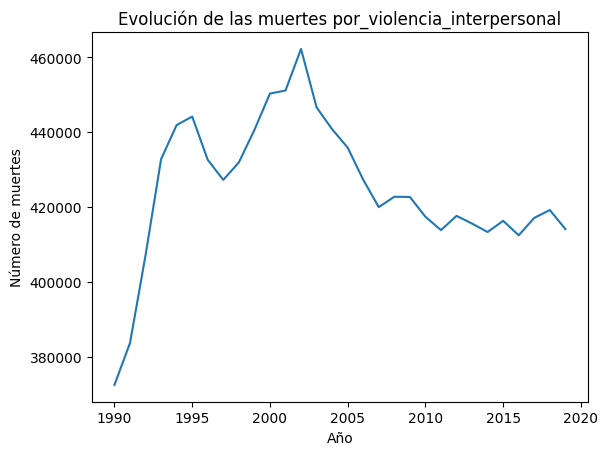

In [39]:
#En esta celda vamos a represantar los fallecidos por la enfermedad que escribamos, y su evolucion...

import matplotlib.pyplot as plt
import seaborn as sns

df_agrupado = df_tabla_limpia.groupby('año')['por_violencia_interpersonal'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_violencia_interpersonal'].sum().reset_index()


sns.lineplot(x='año', y='por_violencia_interpersonal', data=df_enfermedad)
plt.title('Evolución de las muertes por_violencia_interpersonal')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

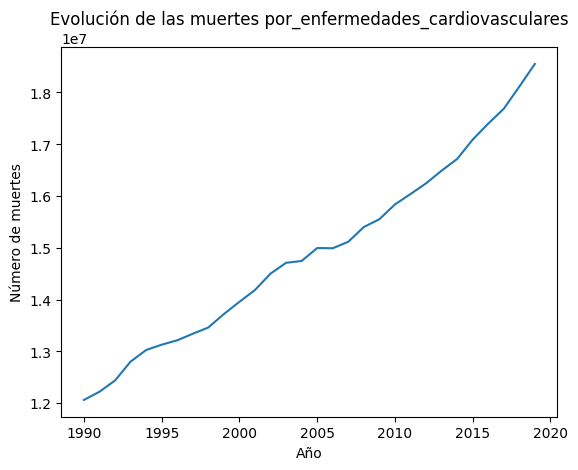

In [43]:
df_agrupado = df_tabla_limpia.groupby('año')['por_enfermedades_cardiovasculares'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_enfermedades_cardiovasculares'].sum().reset_index()


sns.lineplot(x='año', y='por_enfermedades_cardiovasculares', data=df_enfermedad)
plt.title('Evolución de las muertes por enfermedades cardiovasculares')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

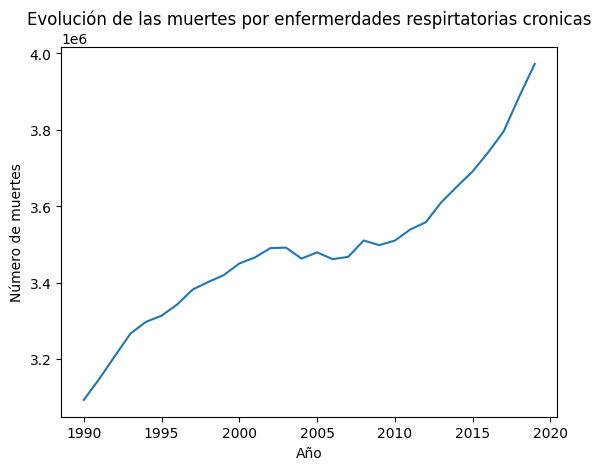

In [49]:
df_agrupado = df_tabla_limpia.groupby('año')['por_enfermerdades_respirtatorias_cronicas'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_enfermerdades_respirtatorias_cronicas'].sum().reset_index()


sns.lineplot(x='año', y='por_enfermerdades_respirtatorias_cronicas', data=df_enfermedad)
plt.title('Evolución de las muertes por enfermerdades respirtatorias cronicas')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

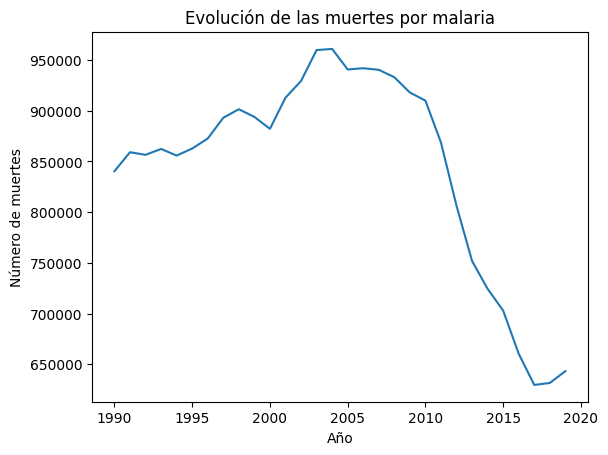

In [45]:
df_agrupado = df_tabla_limpia.groupby('año')['por_malaria'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_malaria'].sum().reset_index()


sns.lineplot(x='año', y='por_malaria', data=df_enfermedad)
plt.title('Evolución de las muertes por malaria')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

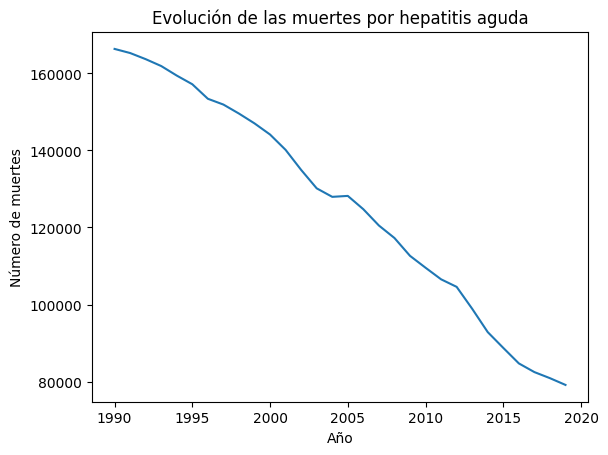

In [46]:
df_agrupado = df_tabla_limpia.groupby('año')['por_hepatitis_aguda'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_hepatitis_aguda'].sum().reset_index()


sns.lineplot(x='año', y='por_hepatitis_aguda', data=df_enfermedad)
plt.title('Evolución de las muertes por hepatitis aguda')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

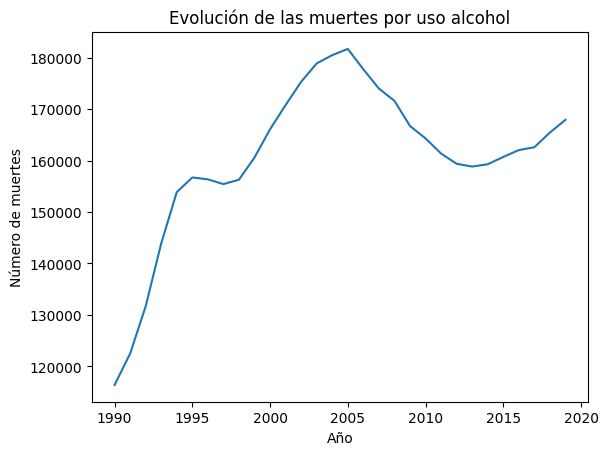

In [47]:
df_agrupado = df_tabla_limpia.groupby('año')['por_uso_alcohol'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_uso_alcohol'].sum().reset_index()


sns.lineplot(x='año', y='por_uso_alcohol', data=df_enfermedad)
plt.title('Evolución de las muertes por uso alcohol')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

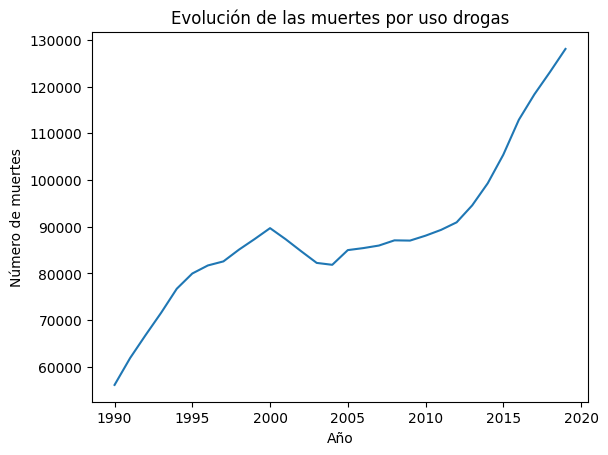

In [48]:
df_agrupado = df_tabla_limpia.groupby('año')['por_uso_drogas'].sum().reset_index()
df_enfermedad = df_tabla_limpia.groupby('año')['por_uso_drogas'].sum().reset_index()


sns.lineplot(x='año', y='por_uso_drogas', data=df_enfermedad)
plt.title('Evolución de las muertes por uso drogas')
plt.xlabel('Año')
plt.ylabel('Número de muertes')
plt.show()

In [40]:
df_tabla_limpia.to_excel('tabla.xlsx', index=False)

In [41]:
df_top20.to_excel('top20.xlsx', index=False)

In [42]:
df_espana_comparar.to_excel('espana.xlsx', index=False)